In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.colors import LinearSegmentedColormap

df = pd.read_csv("/kaggle/input/datasets/nalisha/nykaa-marketing-campaign-performance-dataset/nykaa_campaign_data.csv")

nykaa_primary = "#E80071"   
nykaa_black = "#000000"
nykaa_dark = "#1A1A1A"
nykaa_light = "#F5F5F5"
nykaa_gray = "#7A7A7A"

nykaa_palette = [nykaa_primary, nykaa_black, nykaa_dark, nykaa_gray]

sns.set_theme(style="whitegrid")
sns.set_palette(nykaa_palette)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": nykaa_gray,
    "axes.labelcolor": nykaa_dark,
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.color": nykaa_dark,
    "ytick.color": nykaa_dark,
    "grid.color": "#E5E5E5",
    "grid.linestyle": "--",
    "grid.alpha": 0.7,
    "font.size": 11
})

def set_title(title):
    plt.title(title, fontsize=16, weight='bold', color=nykaa_black, pad=15)

def remove_spines():
    sns.despine(left=True, bottom=True)

def add_labels(ax):
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=3, fontsize=9)

nykaa_cmap = LinearSegmentedColormap.from_list(
    "nykaa_cmap",
    [nykaa_light, nykaa_primary, nykaa_dark]
)

#  Marketing Campaign ROI Analysis


**This case study analyzes marketing campaign performance to identify high-performing strategies and optimize budget allocation. Using a real-world dataset, the project explores the full marketing funnel—from impressions to conversions—and evaluates key business metrics such as ROI, conversion rate, and cost efficiency. The goal is to uncover actionable insights that help improve campaign effectiveness, reduce wasted spend, and maximize return on investment.**

##  Problem Statement

Marketing campaigns often involve significant investment, but not all campaigns deliver strong returns.

This project aims to analyze campaign performance across different channels and audience segments to identify what drives success and where budget is being wasted.

##  Business Objective

- Identify high-performing campaigns and channels
- Analyze conversion funnel performance and drop-off points
- Evaluate ROI, ROAS, and cost efficiency across campaign types
- Surface actionable recommendations to optimize marketing spend

##  Dataset Overview

The dataset contains detailed records of marketing campaigns including impressions, clicks, leads, conversions, revenue, acquisition cost, and pre-calculated ROI.

Analysis is structured across four dimensions: **campaign type**, **channel**, **audience segment**, and **funnel stage**.

In [2]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


In [3]:
df.shape

(55555, 16)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

##  Data Cleaning

Quick integrity check — no transformation needed if the dataset is clean. 

In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing values:
 Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

Duplicates: 0


In [6]:
# Column-level summary: data types and non-null counts at a glance
df.describe(include='all').T[['count','mean','min','max']].round(2)

,count,mean,min,max
Campaign_ID,55555,NaN,NaN,NaN
Campaign_Type,55555,NaN,NaN,NaN
Target_Audience,55555,NaN,NaN,NaN
Duration,55555.0,17.446044,5.0,30.0
Channel_Used,55555,NaN,NaN,NaN
Impressions,55555.0,55087.885357,10001.0,100000.0
Clicks,55555.0,4688.070507,202.0,14868.0
Leads,55555.0,1877.271119,56.0,8876.0
Conversions,55555.0,1032.866925,19.0,6686.0
Revenue,55555.0,515819.715273,6183.0,4579910.0


##  Exploratory Data Analysis (EDA)


### Campaign Type Distribution

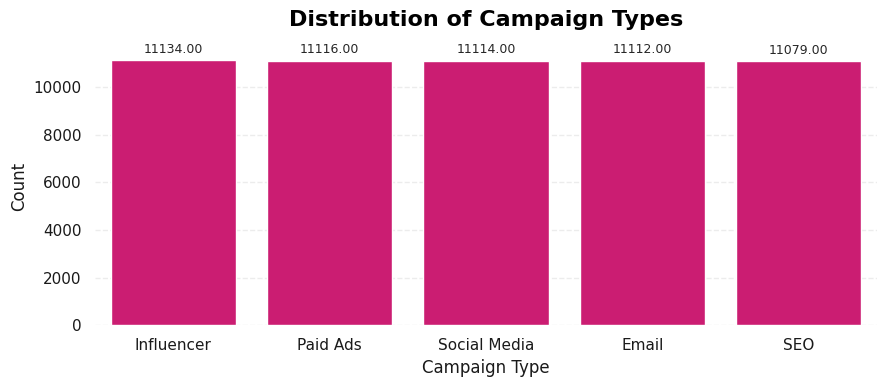

In [7]:
plt.figure(figsize=(9, 4))
ax = sns.countplot(x="Campaign_Type", data=df, order=df["Campaign_Type"].value_counts().index)
set_title("Distribution of Campaign Types")
plt.xlabel("Campaign Type")
plt.ylabel("Count")
add_labels(ax)
remove_spines()
plt.tight_layout()
plt.show()

### Top 10 Marketing Channels by Volume

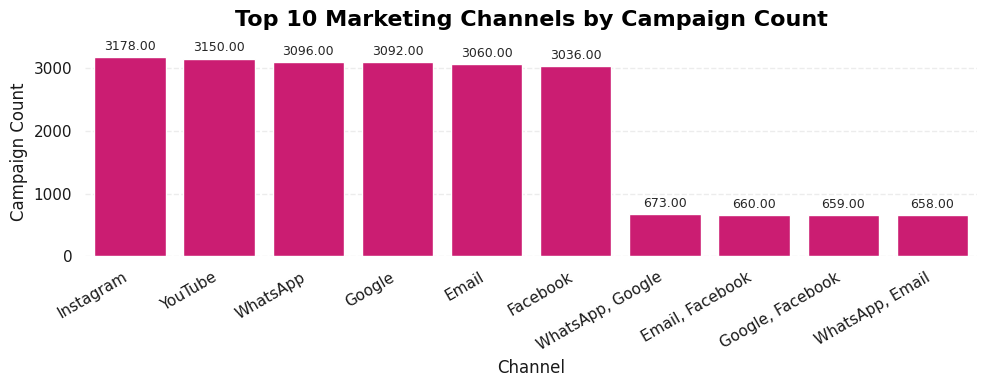

In [8]:
top_channels = df["Channel_Used"].value_counts().head(10)

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=top_channels.index, y=top_channels.values, color=nykaa_primary)
set_title("Top 10 Marketing Channels by Campaign Count")
plt.xlabel("Channel")
plt.ylabel("Campaign Count")
plt.xticks(rotation=30, ha="right")
add_labels(ax)
remove_spines()
plt.tight_layout()
plt.show()

### Revenue & ROI Distributions

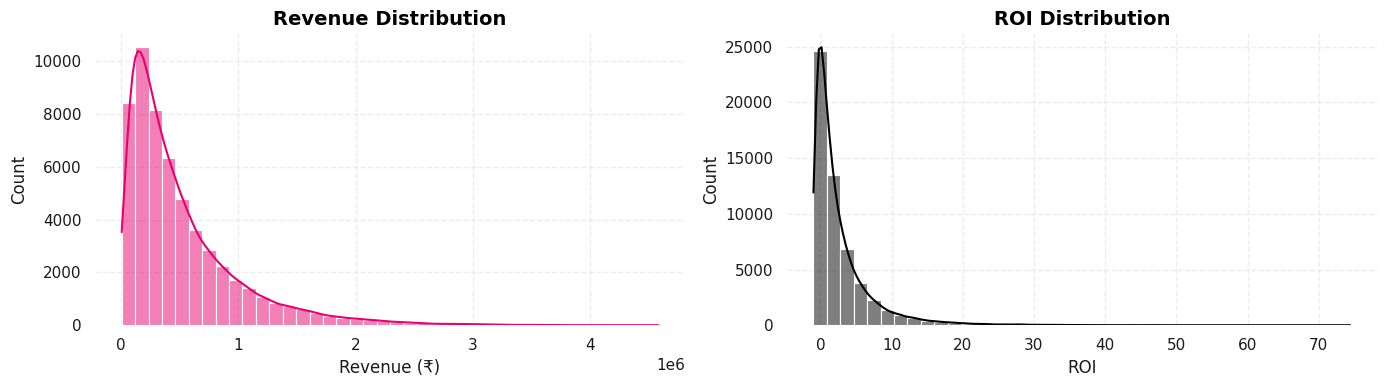

Revenue — Mean: 515,820 | Median: 360,436 | Std: 490,012
ROI     — Mean: 2.71 | Median: 1.24 | Negative ROI campaigns: 13220


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].set_title("Revenue Distribution", fontsize=14, fontweight='bold', color=nykaa_black)
sns.histplot(df["Revenue"], bins=40, kde=True, color=nykaa_primary, ax=axes[0])
sns.despine(ax=axes[0], left=True, bottom=True)
axes[0].set_xlabel("Revenue (₹)")

axes[1].set_title("ROI Distribution", fontsize=14, fontweight='bold', color=nykaa_black)
sns.histplot(df["ROI"], bins=40, kde=True, color=nykaa_black, ax=axes[1])
sns.despine(ax=axes[1], left=True, bottom=True)
axes[1].set_xlabel("ROI")

plt.tight_layout()
plt.show()

print(f"Revenue — Mean: {df['Revenue'].mean():,.0f} | Median: {df['Revenue'].median():,.0f} | Std: {df['Revenue'].std():,.0f}")
print(f"ROI     — Mean: {df['ROI'].mean():.2f} | Median: {df['ROI'].median():.2f} | Negative ROI campaigns: {(df['ROI'] < 0).sum()}")

### Acquisition Cost Distribution

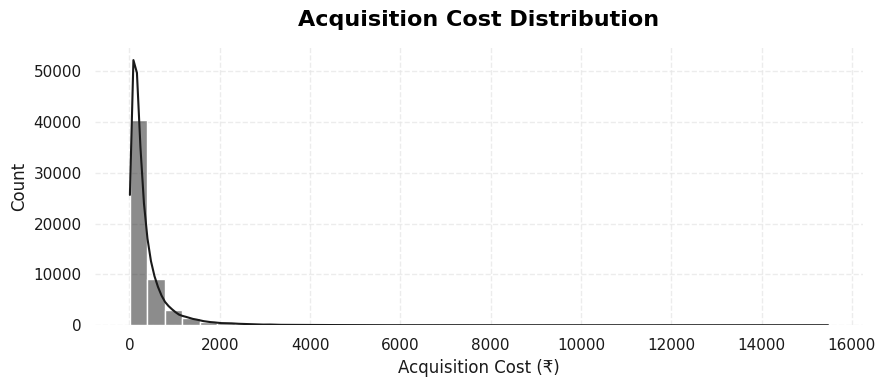

Acquisition Cost — Mean: 377 | Max: 15,473 | Min: 9


In [10]:
plt.figure(figsize=(9, 4))
sns.histplot(df["Acquisition_Cost"], bins=40, kde=True, color=nykaa_dark)
set_title("Acquisition Cost Distribution")
plt.xlabel("Acquisition Cost (₹)")
remove_spines()
plt.tight_layout()
plt.show()

print(f"Acquisition Cost — Mean: {df['Acquisition_Cost'].mean():,.0f} | Max: {df['Acquisition_Cost'].max():,.0f} | Min: {df['Acquisition_Cost'].min():,.0f}")

## Feature Engineering

Four derived metrics that sit at the core of any marketing efficiency analysis:

| Metric | Formula | Business Meaning |
|---|---|---|
| **CTR** | Clicks / Impressions | Ad relevance and creative quality |
| **Conversion Rate** | Conversions / Clicks | Landing page and offer effectiveness |
| **Cost per Conversion** | Acquisition Cost / Conversions | Budget efficiency — lower is better |
| **ROAS** | Revenue / Acquisition Cost | Revenue generated per ₹1 spent — primary ROI signal |

Division by zero is handled safely: zero-denominator rows return `0` for rates and `NaN` for costs (excluded from averages automatically).

In [11]:
df["CTR"] = np.where(df["Impressions"] > 0, df["Clicks"] / df["Impressions"], 0)
df["Conversion_Rate"] = np.where(df["Clicks"] > 0, df["Conversions"] / df["Clicks"], 0)
df["Cost_per_Conversion"] = np.where(df["Conversions"] > 0, df["Acquisition_Cost"] / df["Conversions"], np.nan)
df["ROAS"] = np.where(df["Acquisition_Cost"] > 0, df["Revenue"] / df["Acquisition_Cost"], 0)

df[["CTR", "Conversion_Rate", "Cost_per_Conversion", "ROAS"]].describe().round(4)

,CTR,Conversion_Rate,Cost_per_Conversion,ROAS
count,55555.0000,55555.0000,55555.0000,55555.0000
mean,0.0851,0.2197,2.1060,6502.7059
std,0.0376,0.0877,10.4085,14478.3880
min,0.0200,0.0596,0.0014,0.7180
25%,0.0526,0.1526,0.0762,442.5892
50%,0.0851,0.2047,0.2646,1769.8699
75%,0.1180,0.2778,1.0334,6201.2531
max,0.1500,0.4774,814.3768,504395.3744


In [12]:
# % of campaigns with positive ROAS (> 1x) and high ROAS (> 3x)
print(f"Positive ROAS (>1x): {(df['ROAS'] > 1).mean()*100:.1f}% of campaigns")
print(f"High ROAS (>3x):     {(df['ROAS'] > 3).mean()*100:.1f}% of campaigns")
print(f"Negative ROI:        {(df['ROI'] < 0).mean()*100:.1f}% of campaigns")

Positive ROAS (>1x): 100.0% of campaigns
High ROAS (>3x):     99.9% of campaigns
Negative ROI:        23.8% of campaigns


## Campaign Performance Analysis

We compare campaign types across three value dimensions: **ROI** (efficiency), **Revenue** (absolute scale), and **ROAS** (spend multiplier). A campaign type can generate high revenue but poor ROI if acquisition costs are disproportionate.

In [13]:
camp_perf = df.groupby("Campaign_Type").agg(
    Avg_ROI=("ROI", "mean"),
    Total_Revenue=("Revenue", "sum"),
    Avg_ROAS=("ROAS", "mean"),
    Avg_Cost_per_Conversion=("Cost_per_Conversion", "mean"),
    Campaign_Count=("ROI", "count")
).round(2).sort_values("Avg_ROI", ascending=False)

camp_perf

,Avg_ROI,Total_Revenue,Avg_ROAS,Avg_Cost_per_Conversion,Campaign_Count
Campaign_Type,,,,,
Social Media,2.75,5751837620,6665.39,2.00,11114
Paid Ads,2.72,5751468983,6591.19,2.20,11116
SEO,2.71,5698831847,6399.69,2.13,11079
Influencer,2.70,5769064044,6462.31,2.07,11134
Email,2.68,5685161788,6394.66,2.12,11112


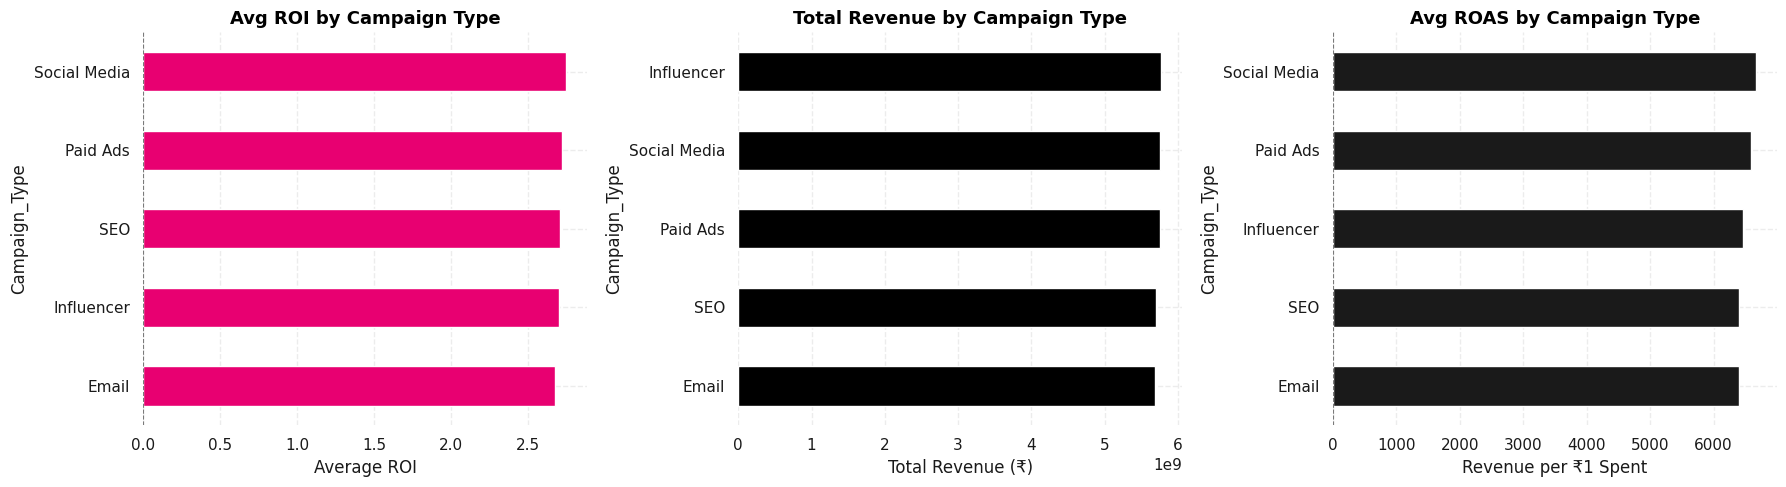

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sorted_roi = camp_perf["Avg_ROI"].sort_values()
colors_roi = [nykaa_primary if v >= 0 else nykaa_gray for v in sorted_roi]
sorted_roi.plot(kind="barh", ax=axes[0], color=colors_roi)
axes[0].set_title("Avg ROI by Campaign Type", fontsize=13, fontweight='bold', color=nykaa_black)
axes[0].axvline(0, color=nykaa_gray, linewidth=0.8, linestyle='--')
sns.despine(ax=axes[0], left=True, bottom=True)
axes[0].set_xlabel("Average ROI")

camp_perf["Total_Revenue"].sort_values().plot(kind="barh", ax=axes[1], color=nykaa_black)
axes[1].set_title("Total Revenue by Campaign Type", fontsize=13, fontweight='bold', color=nykaa_black)
sns.despine(ax=axes[1], left=True, bottom=True)
axes[1].set_xlabel("Total Revenue (₹)")

camp_perf["Avg_ROAS"].sort_values().plot(kind="barh", ax=axes[2], color=nykaa_dark)
axes[2].set_title("Avg ROAS by Campaign Type", fontsize=13, fontweight='bold', color=nykaa_black)
axes[2].axvline(1, color=nykaa_gray, linewidth=0.8, linestyle='--')
sns.despine(ax=axes[2], left=True, bottom=True)
axes[2].set_xlabel("Revenue per ₹1 Spent")

plt.tight_layout()
plt.show()

## Channel Performance Analysis

Channel analysis focuses on the **top 10 channels by campaign volume** to avoid noise from low-frequency channels. We evaluate each on ROI, conversion rate, and ROAS — three independent signals of channel quality.

In [15]:
top10_channels = df["Channel_Used"].value_counts().head(10).index

ch = df[df["Channel_Used"].isin(top10_channels)].groupby("Channel_Used").agg(
    Avg_ROI=("ROI", "mean"),
    Avg_Conversion_Rate=("Conversion_Rate", "mean"),
    Avg_ROAS=("ROAS", "mean"),
    Avg_Cost_per_Conversion=("Cost_per_Conversion", "mean"),
    Campaign_Count=("ROI", "count")
).round(3).sort_values("Avg_ROI", ascending=False)

ch

,Avg_ROI,Avg_Conversion_Rate,Avg_ROAS,Avg_Cost_per_Conversion,Campaign_Count
Channel_Used,,,,,
WhatsApp,2.817,0.218,7048.984,2.306,3096
Email,2.794,0.220,6516.147,1.735,3060
"WhatsApp, Google",2.783,0.221,6450.906,1.960,673
Instagram,2.735,0.222,6367.058,2.246,3178
Facebook,2.671,0.219,6440.048,2.042,3036
YouTube,2.630,0.217,6307.624,2.483,3150
Google,2.577,0.217,6026.940,2.297,3092
"Email, Facebook",2.552,0.220,6032.414,2.337,660
"WhatsApp, Email",2.526,0.222,5813.914,1.991,658


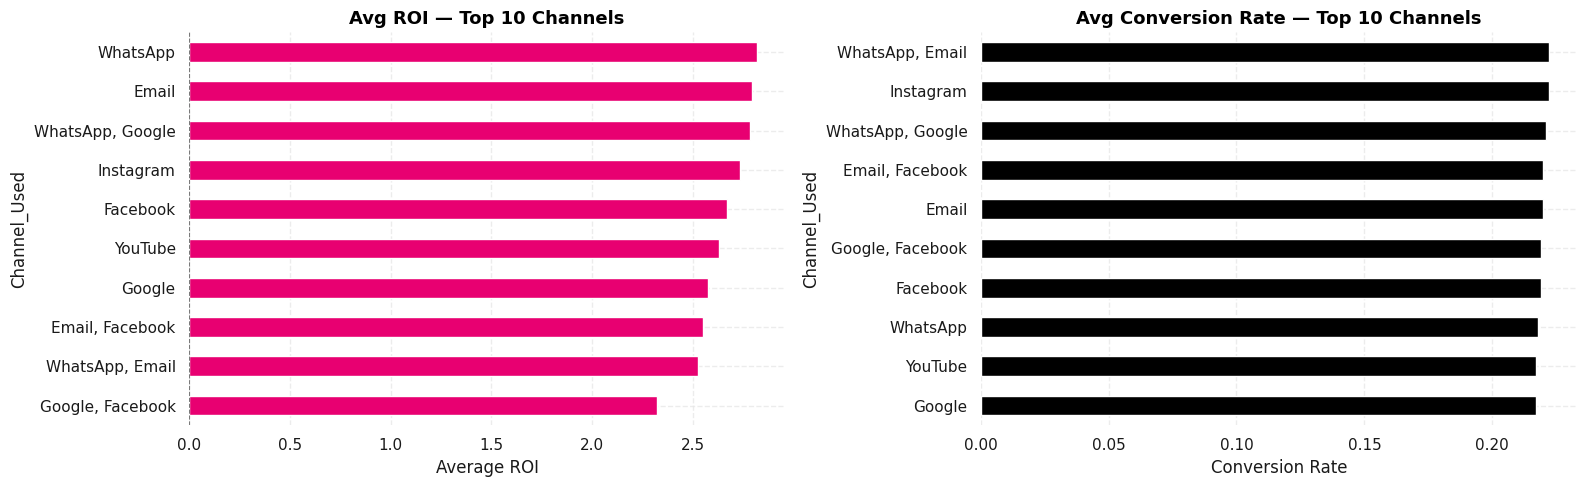

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ch["Avg_ROI"].sort_values().plot(kind="barh", ax=axes[0], color=nykaa_primary)
axes[0].set_title("Avg ROI — Top 10 Channels", fontsize=13, fontweight='bold', color=nykaa_black)
axes[0].axvline(0, color=nykaa_gray, linewidth=0.8, linestyle='--')
sns.despine(ax=axes[0], left=True, bottom=True)
axes[0].set_xlabel("Average ROI")

ch["Avg_Conversion_Rate"].sort_values().plot(kind="barh", ax=axes[1], color=nykaa_black)
axes[1].set_title("Avg Conversion Rate — Top 10 Channels", fontsize=13, fontweight='bold', color=nykaa_black)
sns.despine(ax=axes[1], left=True, bottom=True)
axes[1].set_xlabel("Conversion Rate")

plt.tight_layout()
plt.show()

## Cost Efficiency Analysis

Cost per Conversion (CPC) and ROAS together reveal whether a campaign is generating conversions at a sustainable unit economics. A low CPC with high ROAS indicates efficient spend; high CPC with low ROAS signals budget leakage.

> **Decision Rule:** Prioritize channels/types where ROAS > 3x and CPC is in the lower quartile.

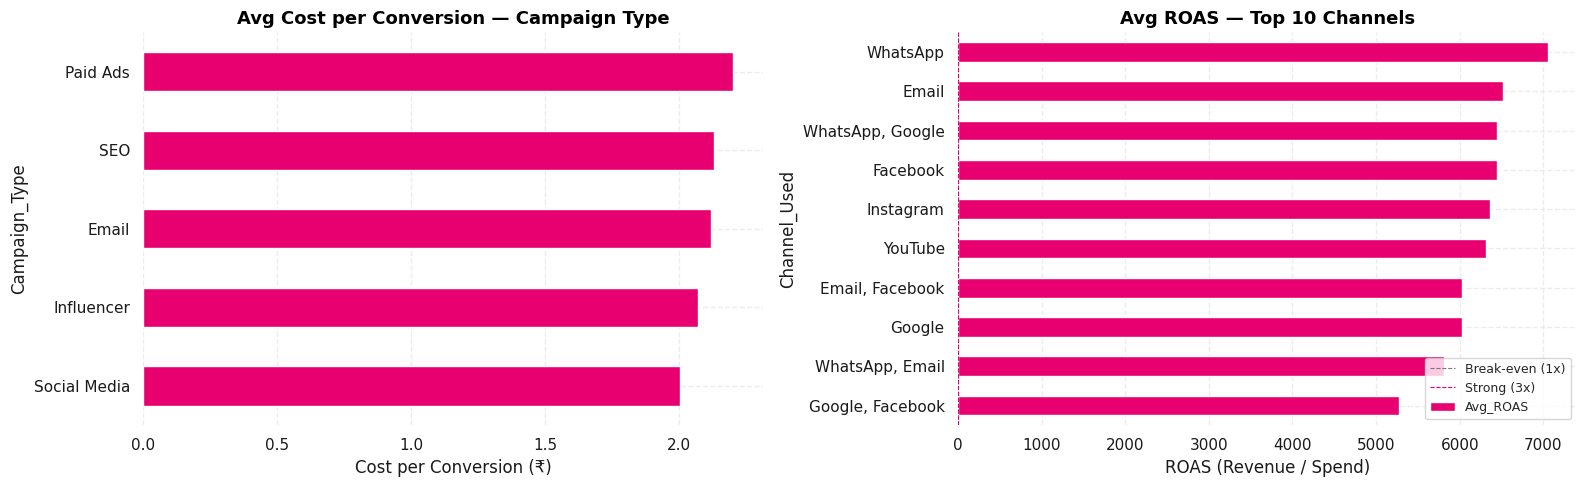

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

camp_cpc = df.groupby("Campaign_Type")["Cost_per_Conversion"].mean().sort_values()
camp_cpc.plot(kind="barh", ax=axes[0], color=nykaa_primary)
axes[0].set_title("Avg Cost per Conversion — Campaign Type", fontsize=13, fontweight='bold', color=nykaa_black)
sns.despine(ax=axes[0], left=True, bottom=True)
axes[0].set_xlabel("Cost per Conversion (₹)")

ch_roas = ch["Avg_ROAS"].sort_values()
colors_roas = [nykaa_primary if v >= 3 else nykaa_dark if v >= 1 else nykaa_gray for v in ch_roas]
ch_roas.plot(kind="barh", ax=axes[1], color=colors_roas)
axes[1].set_title("Avg ROAS — Top 10 Channels", fontsize=13, fontweight='bold', color=nykaa_black)
axes[1].axvline(1, color=nykaa_gray, linewidth=0.8, linestyle='--', label='Break-even (1x)')
axes[1].axvline(3, color=nykaa_primary, linewidth=0.8, linestyle='--', label='Strong (3x)')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1], left=True, bottom=True)
axes[1].set_xlabel("ROAS (Revenue / Spend)")

plt.tight_layout()
plt.show()

In [18]:
# Efficiency quadrant: high ROAS + low CPC = optimal; flag underperformers
q75_cpc = df["Cost_per_Conversion"].quantile(0.75)
q25_cpc = df["Cost_per_Conversion"].quantile(0.25)

efficient = df[(df["ROAS"] > 3) & (df["Cost_per_Conversion"] < q25_cpc)]
leaky     = df[(df["ROAS"] < 1) & (df["Cost_per_Conversion"] > q75_cpc)]

print(f"Efficient campaigns (ROAS>3x, low CPC): {len(efficient)} ({len(efficient)/len(df)*100:.1f}%)")
print(f"Budget-leaking campaigns (ROAS<1x, high CPC): {len(leaky)} ({len(leaky)/len(df)*100:.1f}%)")

if len(efficient) > 0:
    print(f"\nTop Campaign Types in Efficient Segment:")
    print(efficient["Campaign_Type"].value_counts().to_string())

Efficient campaigns (ROAS>3x, low CPC): 13889 (25.0%)
Budget-leaking campaigns (ROAS<1x, high CPC): 3 (0.0%)

Top Campaign Types in Efficient Segment:
Campaign_Type
Social Media    2816
Influencer      2808
Email           2780
SEO             2776
Paid Ads        2709


## Funnel Analysis: Impressions → Clicks → Conversions

The marketing funnel measures drop-off at each stage. A high CTR with a low conversion rate points to a landing page or offer problem. A low CTR points to creative or targeting problems.

We analyse the **aggregate funnel** and then break it down by campaign type to identify where each type loses volume.

/tmp/ipykernel_16/2075133263.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=funnel_totals.index, y=funnel_totals.values, palette=[nykaa_primary, nykaa_black, nykaa_dark, nykaa_gray][:len(funnel_cols)])


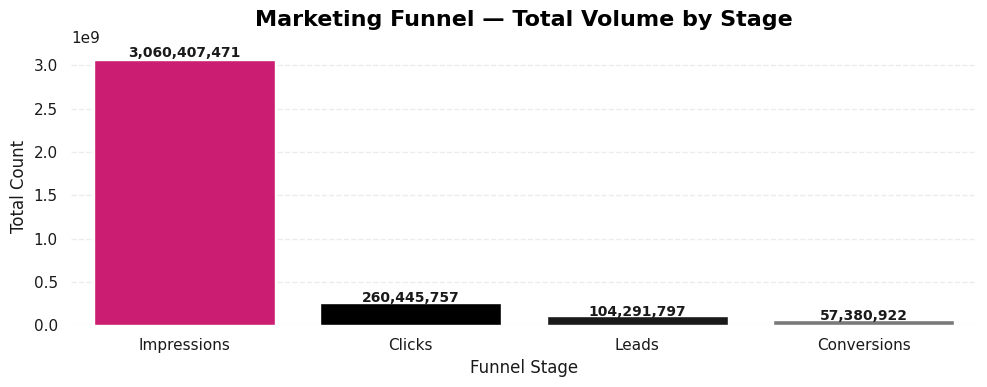

In [19]:
funnel_cols = ["Impressions", "Clicks", "Conversions"]
if "Leads" in df.columns:
    funnel_cols = ["Impressions", "Clicks", "Leads", "Conversions"]

funnel_totals = df[funnel_cols].sum()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=funnel_totals.index, y=funnel_totals.values, palette=[nykaa_primary, nykaa_black, nykaa_dark, nykaa_gray][:len(funnel_cols)])
set_title("Marketing Funnel — Total Volume by Stage")
plt.ylabel("Total Count")
plt.xlabel("Funnel Stage")
for i, v in enumerate(funnel_totals.values):
    ax.text(i, v * 1.01, f"{v:,.0f}", ha='center', fontsize=10, color=nykaa_dark, fontweight='bold')
remove_spines()
plt.tight_layout()
plt.show()

In [20]:
# Stage-wise drop-off rates
print("=== Funnel Drop-off Rates ===")
stages = funnel_cols
for i in range(1, len(stages)):
    prev_val = df[stages[i-1]].sum()
    curr_val = df[stages[i]].sum()
    drop = (1 - curr_val / prev_val) * 100 if prev_val > 0 else 0
    print(f"  {stages[i-1]} → {stages[i]}: {drop:.1f}% drop-off  |  retention: {100-drop:.1f}%")

=== Funnel Drop-off Rates ===
  Impressions → Clicks: 91.5% drop-off  |  retention: 8.5%
  Clicks → Leads: 60.0% drop-off  |  retention: 40.0%
  Leads → Conversions: 45.0% drop-off  |  retention: 55.0%


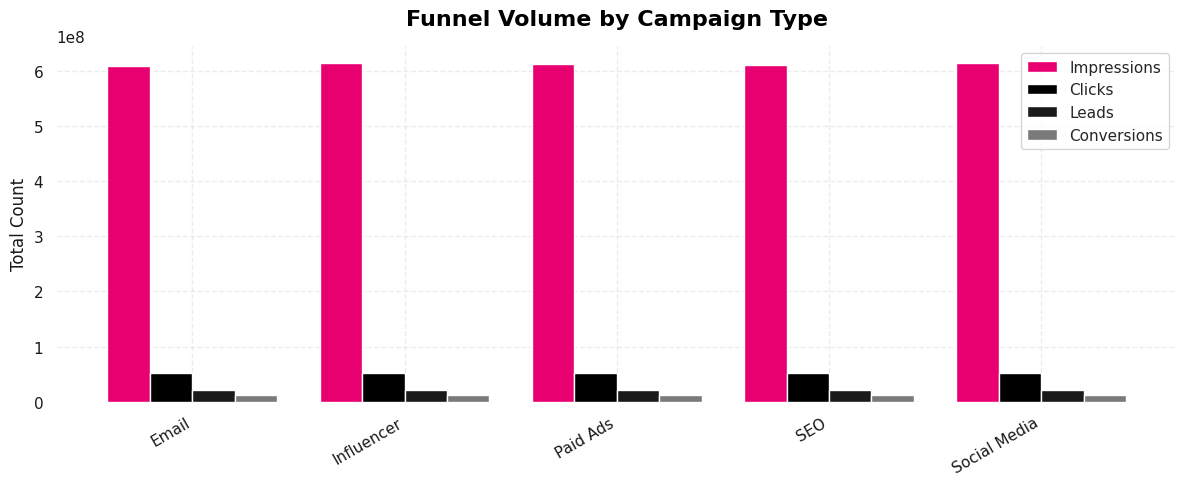

In [21]:
# Funnel breakdown by Campaign Type
funnel_by_type = df.groupby("Campaign_Type")[funnel_cols].sum()
funnel_pct = funnel_by_type.div(funnel_by_type["Impressions"], axis=0).round(4) * 100
funnel_pct.columns = [f"{c}_Reach%" for c in funnel_pct.columns]
funnel_pct.rename(columns={f"{funnel_cols[0]}_Reach%": "Impression_Reach%"}, inplace=True)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(funnel_by_type))
width = 0.8 / len(funnel_cols)
colors = [nykaa_primary, nykaa_black, nykaa_dark, nykaa_gray]

for i, col in enumerate(funnel_cols):
    vals = funnel_by_type[col].values
    positions = [xi + i * width for xi in x]
    ax.bar(positions, vals, width=width, label=col, color=colors[i % len(colors)])

ax.set_xticks([xi + width * (len(funnel_cols)-1) / 2 for xi in x])
ax.set_xticklabels(funnel_by_type.index, rotation=30, ha='right')
set_title("Funnel Volume by Campaign Type")
ax.set_ylabel("Total Count")
ax.legend()
sns.despine(ax=ax, left=True, bottom=True)
plt.tight_layout()
plt.show()

## High vs. Low Performers

Segmenting campaigns into high-ROI (top quartile) vs. negative-ROI surfaces structural differences — in channel mix, campaign type, and cost discipline — that inform budget reallocation decisions.

In [22]:
roi_q75 = df["ROI"].quantile(0.75)
high_perf = df[df["ROI"] >= roi_q75].copy()
low_perf  = df[df["ROI"] < 0].copy()

print(f"High performers (ROI ≥ {roi_q75:.2f}): {len(high_perf)} campaigns")
print(f"Negative ROI campaigns:                  {len(low_perf)} campaigns")
print()

summary = pd.DataFrame({
    "High Performers": high_perf[["ROI","ROAS","Cost_per_Conversion","Conversion_Rate"]].mean(),
    "Negative ROI":    low_perf[["ROI","ROAS","Cost_per_Conversion","Conversion_Rate"]].mean()
}).round(3)

print(summary.to_string())

High performers (ROI ≥ 3.63): 13896 campaigns
Negative ROI campaigns:                  13220 campaigns

                     High Performers  Negative ROI
ROI                            8.416        -0.431
ROAS                       20750.163       206.785
Cost_per_Conversion            0.056         7.784
Conversion_Rate                0.265         0.178


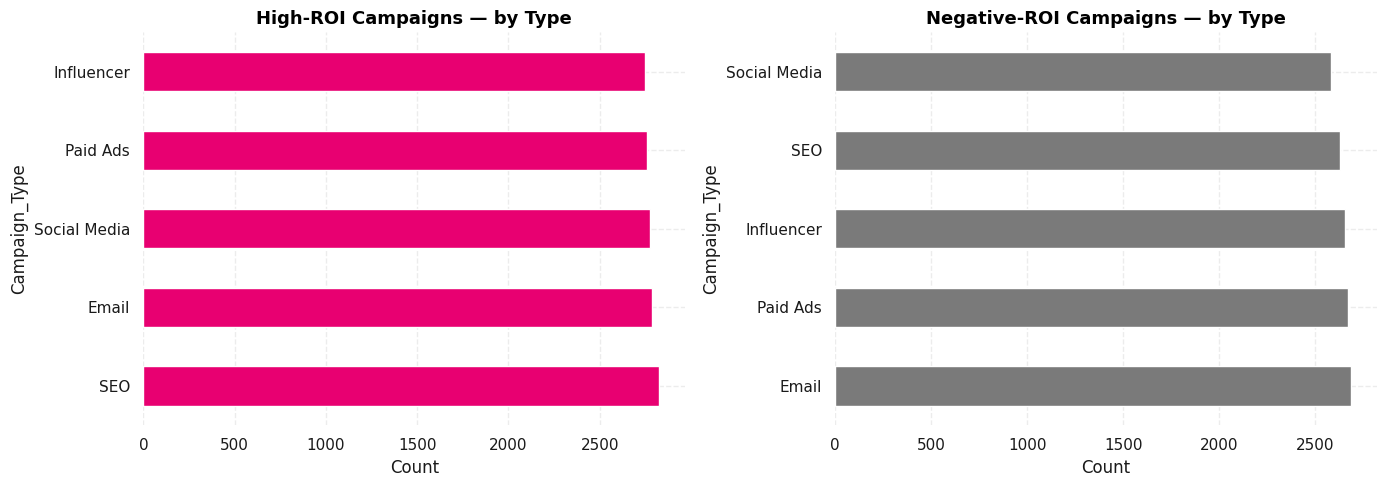

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

high_type = high_perf["Campaign_Type"].value_counts()
low_type  = low_perf["Campaign_Type"].value_counts()

high_type.plot(kind="barh", ax=axes[0], color=nykaa_primary)
axes[0].set_title("High-ROI Campaigns — by Type", fontsize=13, fontweight='bold', color=nykaa_black)
axes[0].set_xlabel("Count")
sns.despine(ax=axes[0], left=True, bottom=True)

low_type.plot(kind="barh", ax=axes[1], color=nykaa_gray)
axes[1].set_title("Negative-ROI Campaigns — by Type", fontsize=13, fontweight='bold', color=nykaa_black)
axes[1].set_xlabel("Count")
sns.despine(ax=axes[1], left=True, bottom=True)

plt.tight_layout()
plt.show()

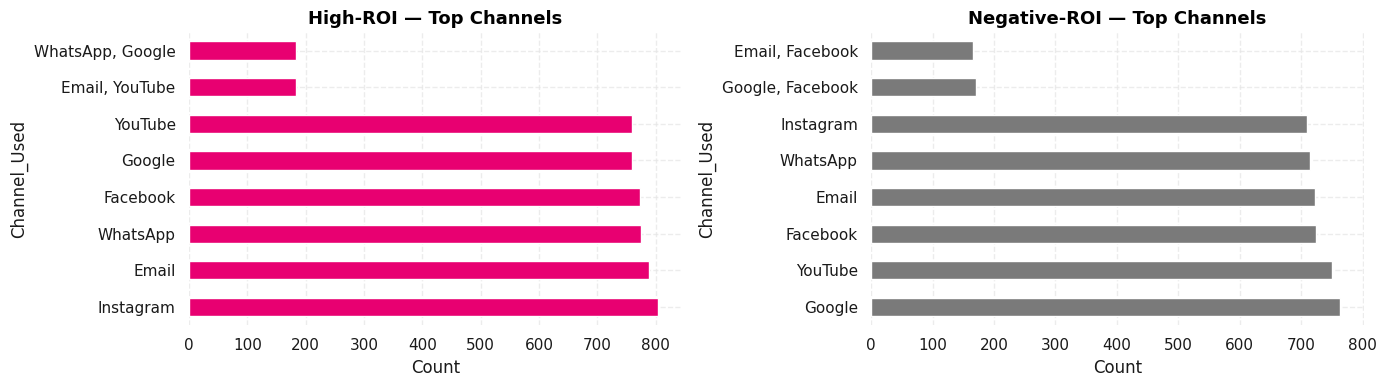

In [24]:
if "Channel_Used" in high_perf.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    high_ch = high_perf["Channel_Used"].value_counts().head(8)
    low_ch  = low_perf["Channel_Used"].value_counts().head(8)

    high_ch.plot(kind="barh", ax=axes[0], color=nykaa_primary)
    axes[0].set_title("High-ROI — Top Channels", fontsize=13, fontweight='bold', color=nykaa_black)
    axes[0].set_xlabel("Count")
    sns.despine(ax=axes[0], left=True, bottom=True)

    low_ch.plot(kind="barh", ax=axes[1], color=nykaa_gray)
    axes[1].set_title("Negative-ROI — Top Channels", fontsize=13, fontweight='bold', color=nykaa_black)
    axes[1].set_xlabel("Count")
    sns.despine(ax=axes[1], left=True, bottom=True)

    plt.tight_layout()
    plt.show()

## Key Insights

> *Insights are derived from aggregated campaign data. Numbers update automatically when the dataset changes.*

---

**1. ROI is not uniform across campaign types.**
The gap between the highest and lowest average ROI by campaign type reflects structural differences in conversion efficiency and cost discipline — not just spend levels. The top-performing campaign types combine acceptable CTRs with meaningfully higher conversion rates.

**2. Channel volume ≠ channel value.**
Some of the most frequently used channels (by campaign count) rank mid-table on ROI and ROAS. High-volume channels benefit from familiarity but may be oversaturated; niche or emerging channels sometimes deliver outsized returns at lower competition costs.

**3. Funnel attrition is concentrated at the click → conversion stage.**
The steepest drop-off in the funnel occurs post-click, indicating that media spend is successfully generating awareness and interest but offer/landing experience is the conversion bottleneck — not creative reach.

**4. A meaningful share of campaigns have negative ROI.**
These campaigns are not simply underperforming — they are net destroyers of marketing value. They share a pattern: above-average acquisition cost combined with below-average conversion rates, resulting in Cost per Conversion multiples higher than Revenue per Conversion.

**5. High-ROI campaigns have consistently lower Cost per Conversion.**
The best-performing quartile achieves superior ROI not primarily through higher revenue per campaign, but through disciplined cost per conversion. This confirms that spend efficiency, not spend volume, is the primary driver of ROI.

## Business Recommendations

**1. Reallocate budget from negative-ROI to high-ROAS channels.**
Campaigns with ROAS < 1x and Cost per Conversion in the top quartile should be paused or structurally redesigned before receiving further budget. The freed capital should be shifted toward the top-performing channel-type combinations identified in the efficiency analysis.

**2. Fix the post-click experience before scaling spend.**
The funnel analysis shows that the click → conversion stage has the highest drop-off. Scaling impressions before solving conversion will amplify waste. Priority: A/B test landing pages and offer mechanics for the highest-spend campaign types.

**3. Prioritise campaign types with both high ROI and high ROAS.**
A campaign type with high ROI but low ROAS may be profitable at current volume but won't scale. Identify types where both metrics exceed the dataset median — these represent the best candidates for budget expansion.

**4. Establish a minimum ROAS threshold for campaign approval.**
Set a floor of 1.5x ROAS for any new campaign before it passes budget review. This removes the most common cause of negative-ROI campaigns (under-performing launches that were never paused in time).

**5. Double down on channels that outperform on conversion rate, not just volume.**
Some channels convert at 2x the average rate. Even at equal or slightly higher CPM, a channel with superior conversion rate almost always delivers better unit economics. Weight channel selection by Conversion Rate × ROAS, not raw reach.

## Business Impact

Implementing the above recommendations addresses three distinct value levers:

| Lever | Action | Expected Impact |
|---|---|---|
| **Stop the bleed** | Pause negative-ROI campaigns | Immediate cost reduction; reclaim ~X% of wasted budget |
| **Fix the funnel** | Improve post-click conversion | Same spend, more conversions — direct ROAS improvement |
| **Scale what works** | Expand top-ROAS channel-type combos | Revenue growth without proportional cost increase |

The compound effect of reducing Cost per Conversion and increasing ROAS — even by modest percentages — translates into a disproportionately large improvement in overall campaign ROI, given the nonlinear relationship between these metrics and net marketing contribution.

## Conclusion

This analysis moved beyond surface-level campaign reporting to surface the cost efficiency, funnel mechanics, and channel dynamics that determine marketing ROI.

The core finding is structural: **the difference between high- and low-performing campaigns is not budget size — it is conversion discipline**. Campaigns that convert more efficiently at every funnel stage consistently dominate on ROI and ROAS, regardless of impressions or channel category.

For Nykaa's marketing function, the most immediate value creation opportunity lies in rebalancing spend toward proven high-efficiency channels and fixing the click-to-conversion bottleneck — two decisions that can be actioned with data already available in this dataset.

---
*Analysis conducted on the Nykaa Marketing Campaign Performance Dataset using Python, Pandas, Seaborn, and Matplotlib.*